<a href="https://colab.research.google.com/github/aniray2908/nlp-llm-journey/blob/main/00_pytorch_warmup/demos/05_dataloader_training_loop_optimisers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1 — Imports**

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

**Cell 2 — Generate Data**

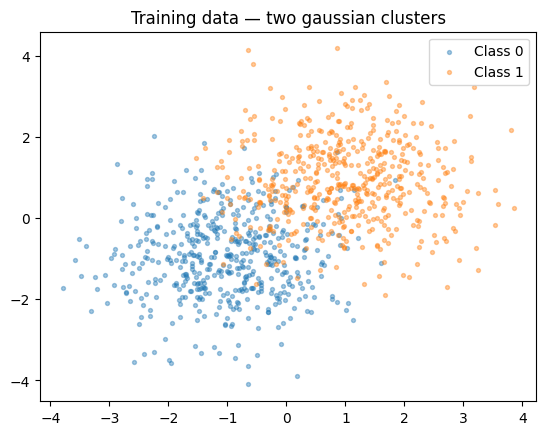

In [2]:
torch.manual_seed(42)

# Two gaussian clusters — class 0 centred at (-1,-1), class 1 at (1,1)
n = 500
X0 = torch.randn(n, 2) + torch.tensor([-1.0, -1.0])
X1 = torch.randn(n, 2) + torch.tensor([ 1.0,  1.0])
X  = torch.cat([X0, X1], dim=0)                      # shape (1000, 2)
y  = torch.cat([torch.zeros(n), torch.ones(n)])       # shape (1000,)

# Visualise
plt.scatter(X[:n, 0], X[:n, 1], s=8, alpha=0.4, label='Class 0')
plt.scatter(X[n:, 0], X[n:, 1], s=8, alpha=0.4, label='Class 1')
plt.legend()
plt.title("Training data — two gaussian clusters")
plt.show()

**Cell 3 — Dataset & DataLoader**

In [3]:
class ClusterDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset  = ClusterDataset(X, y)
train_set, val_set = random_split(dataset, [800, 200])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")   # 25
print(f"Val batches:   {len(val_loader)}")     # 7

Train batches: 25
Val batches:   7


**Cell 4 — Model**

In [4]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)    # raw logit — no sigmoid here
        )

    def forward(self, x):
        return self.net(x).squeeze(1)   # shape (batch,) not (batch, 1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = Classifier().to(device)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

Classifier(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)
Parameters: 337


**Cell 5 — Optimiser & Loss**

In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_fn   = nn.BCEWithLogitsLoss()   # sigmoid + binary cross entropy in one, numerically stable

**Cell 6 — Training Loop**

In [6]:
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(30):

    # ── Training ──
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ── Validation ──
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch  = X_batch.to(device)
            y_batch  = y_batch.to(device)
            logits   = model(X_batch)
            val_loss += loss_fn(logits, y_batch).item()

            # Convert logits → predictions
            preds    = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    accuracy  = correct / total * 100

    train_losses.append(avg_train)
    val_losses.append(avg_val)
    val_accuracies.append(accuracy)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | Acc: {accuracy:.1f}%")

Epoch  5 | Train: 0.5395 | Val: 0.5028 | Acc: 92.5%
Epoch 10 | Train: 0.4004 | Val: 0.3516 | Acc: 92.5%
Epoch 15 | Train: 0.2949 | Val: 0.2467 | Acc: 92.5%
Epoch 20 | Train: 0.2460 | Val: 0.1995 | Acc: 92.5%
Epoch 25 | Train: 0.2281 | Val: 0.1828 | Acc: 92.5%
Epoch 30 | Train: 0.2218 | Val: 0.1762 | Acc: 92.5%


**Cell 7 — Plot Results**

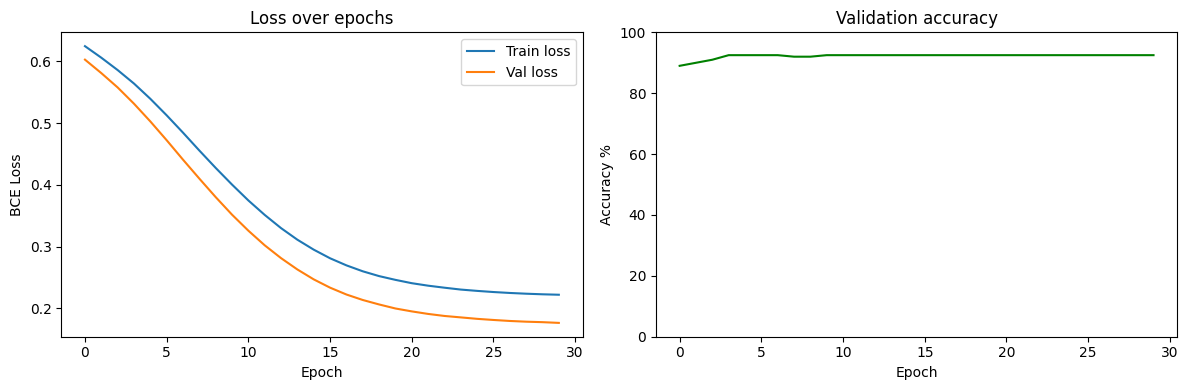

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax1.plot(train_losses, label='Train loss')
ax1.plot(val_losses,   label='Val loss')
ax1.set_title("Loss over epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.legend()

# Accuracy curve
ax2.plot(val_accuracies, color='green')
ax2.set_title("Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy %")
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

**Cell 8 — Visualise the Decision Boundary**

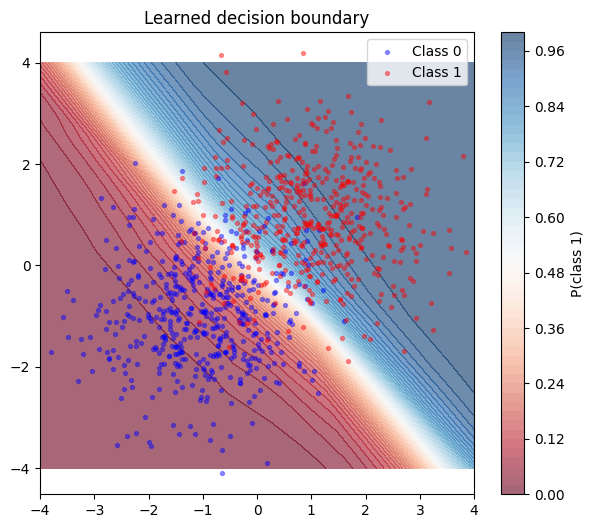

In [8]:
model.eval()
with torch.no_grad():
    # Create a grid of points covering the data space
    xx, yy  = torch.meshgrid(
        torch.linspace(-4, 4, 200),
        torch.linspace(-4, 4, 200),
        indexing='ij'
    )
    grid    = torch.stack([xx.flatten(), yy.flatten()], dim=1).to(device)
    logits  = model(grid)
    probs   = torch.sigmoid(logits).reshape(200, 200).cpu()

# Plot
plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, probs, levels=50, cmap='RdBu', alpha=0.6)
plt.colorbar(label='P(class 1)')
plt.scatter(X[:n, 0], X[:n, 1], s=8, alpha=0.4, c='blue',  label='Class 0')
plt.scatter(X[n:, 0], X[n:, 1], s=8, alpha=0.4, c='red',   label='Class 1')
plt.legend()
plt.title("Learned decision boundary")
plt.show()

**Cell 9 — Save the Model**

In [9]:
torch.save(model.state_dict(), 'classifier.pt')
print("Model saved!")

# Verify it loads correctly
model_loaded = Classifier().to(device)
model_loaded.load_state_dict(torch.load('classifier.pt'))
model_loaded.eval()
print("Model loaded successfully!")

Model saved!
Model loaded successfully!
